# Notebook 5 — Evaluation

**Satellite Image Land-Use Classifier & Temporal Change Detector**

This notebook evaluates the complete pipeline developed in the previous
notebooks.

The fine-tuned land-use classifier and temporal change detection components
are analyzed using performance metrics, visual results, and comparison
summaries. The goal is to measure classification accuracy, generalization
ability, and the effectiveness of the change detection approach.



## Objective

This notebook focuses on evaluating the complete system using three main
experiments:

1. **Spatial Leakage Analysis**  
   Compare performance between a random data split and the spatial block split
   to understand how spatial leakage affects model evaluation.

2. **UC Merced Holdout Evaluation**  
   Test the trained model on the external UC Merced dataset and report
   per-class performance metrics to measure generalization.

3. **Error Analysis**  
   Analyze the most common classification mistakes by identifying the top-5
   confused class pairs, visualizing examples, and discussing possible reasons
   behind these errors.

## Imports

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import f1_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Implementation

### Part 1 — Spatial leakage experiment

We compare two ways of splitting EuroSAT into train/val (same 70/15 ratio):

- **Block split**: the same per-class contiguous split used since Notebook 1
  (keeps "nearby" images together, our proxy for spatial locality).
- **Random split**: the same ratio, but images are shuffled before splitting.

If random splitting lets near-duplicate/adjacent tiles land in both train and
val, validation accuracy under the random split should look inflated compared
to the block split. We train a small baseline CNN (same architecture as
Notebook 2, fast to train) under each split and compare val accuracy.

**Caveat:** this only tests leakage under our assumption that a class's
original image order approximates spatial proximity — the same assumption
used for the spatial block split itself.

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

dataset = datasets.EuroSAT(root="./data", download=True, transform=transform)
class_names = dataset.classes

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# --- Block split (same as Notebook 1) ---
block_train_idx, block_val_idx = [], []
for class_idx in range(len(class_names)):
    class_indices = [i for i, label in enumerate(dataset.targets) if label == class_idx]
    n = len(class_indices)
    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)
    block_train_idx.extend(class_indices[:train_end])
    block_val_idx.extend(class_indices[train_end:val_end])

# --- Random split (same ratio, shuffled with a fixed seed for reproducibility) ---
rng = np.random.default_rng(seed=42)
random_train_idx, random_val_idx = [], []
for class_idx in range(len(class_names)):
    class_indices = [i for i, label in enumerate(dataset.targets) if label == class_idx]
    class_indices = list(class_indices)
    rng.shuffle(class_indices)
    n = len(class_indices)
    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)
    random_train_idx.extend(class_indices[:train_end])
    random_val_idx.extend(class_indices[train_end:val_end])

print("Block split   -> train:", len(block_train_idx), "val:", len(block_val_idx))
print("Random split  -> train:", len(random_train_idx), "val:", len(random_val_idx))

100%|██████████| 94.3M/94.3M [00:02<00:00, 46.2MB/s]


Block split   -> train: 18900 val: 4050
Random split  -> train: 18900 val: 4050


### Load Baseline CNN for Comparison

The baseline CNN trained in Notebook 2 is recreated to compare its performance
against the fine-tuned ResNet-18 model.

This comparison helps measure the improvement gained from transfer learning
over training a CNN from scratch.

In [3]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def train_and_get_val_accuracy(train_idx, val_idx, epochs=3):
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=32, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=32, shuffle=False)

    model = BaselineCNN(num_classes=len(class_names)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [4]:
block_val_accuracy = train_and_get_val_accuracy(block_train_idx, block_val_idx)
random_val_accuracy = train_and_get_val_accuracy(random_train_idx, random_val_idx)

print(f"Block-split val accuracy:  {block_val_accuracy:.3f}")
print(f"Random-split val accuracy: {random_val_accuracy:.3f}")
print(f"Difference (random - block): {random_val_accuracy - block_val_accuracy:+.3f}")

Block-split val accuracy:  0.801
Random-split val accuracy: 0.767
Difference (random - block): -0.034


**Written explanation:** if random-split accuracy comes out higher than
block-split accuracy, that gap is evidence of spatial leakage — under a
random split, images that are "nearby" (by our proxy: close together in the
original per-class ordering) can end up split between train and validation.
Since nearby tiles are often visually very similar, the model may effectively
be validated on near-duplicates of its own training data, inflating the
score. The block split keeps those nearby tiles together on one side of the
split, giving a more realistic estimate of how the model performs on
genuinely unseen regions.

## Part 2 — UC Merced Holdout Evaluation

The fine-tuned ResNet-18 checkpoint from Notebook 3 is evaluated on the UC
Merced Land Use dataset to measure generalization on an external satellite
image dataset.

The same evaluation approach used previously is applied:
- Load the trained model checkpoint.
- Run inference on UC Merced images.
- Compute per-class precision, recall, and F1-score.
- Present the results as a clean metrics table.

No label remapping is performed; the evaluation compares the model's original
EuroSAT label predictions against the UC Merced class labels to understand
cross-dataset performance.### Part 2 — Full evaluation on UC Merced holdout

Reload the Notebook 3 fine-tuned checkpoint and re-run the same UC Merced
evaluation, this time presented as a clean per-class metrics table.

In [6]:
CHECKPOINT_PATH = "model.pt"

if not os.path.exists(CHECKPOINT_PATH):
    print("Checkpoint not found in this session — please upload resnet18_landuse.pt")
    from google.colab import files
    files.upload()

finetuned_model = models.resnet18(weights=None)
finetuned_model.fc = nn.Linear(finetuned_model.fc.in_features, len(class_names))
finetuned_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
finetuned_model = finetuned_model.to(device)
finetuned_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Load UC Merced Holdout Dataset

The UC Merced dataset is used as an external holdout set to evaluate how well
the fine-tuned ResNet-18 model generalizes beyond EuroSAT.

The dataset is loaded from the previously downloaded copy instead of being
downloaded again during runtime.

In [10]:
import kagglehub

path = kagglehub.dataset_download(
    "abdulhasibuddin/uc-merced-land-use-dataset"
)

print("Dataset downloaded to:", path)

100%|██████████| 317M/317M [00:01<00:00, 169MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1


In [11]:
import os

UCM_IMAGES_DIR = os.path.join(
    path,
    "UCMerced_LandUse",
    "Images"
)

print("Images folder:", UCM_IMAGES_DIR)

Images folder: /root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse/Images


In [12]:
print(os.path.exists(UCM_IMAGES_DIR))

True


In [13]:
ucm_dataset = datasets.ImageFolder(
    UCM_IMAGES_DIR,
    transform=transform
)

ucm_loader = DataLoader(
    ucm_dataset,
    batch_size=32,
    shuffle=False
)

print("UC Merced classes:", ucm_dataset.classes)
print("Total UC Merced images:", len(ucm_dataset))

UC Merced classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Total UC Merced images: 2100


## Part 3 — Error Analysis

The final analysis focuses on understanding where the model makes mistakes on
the EuroSAT validation set.

The top-5 most frequent misclassification pairs are identified by comparing
the true labels with the model's predicted labels while excluding correctly
classified samples.

For each confusion pair:
- The number of errors is calculated.
- Example misclassified satellite tiles are visualized.
- A possible reason for the confusion is discussed based on similarities in
  land-use appearance, texture, and landscape patterns.

This helps identify the limitations of the classifier beyond overall accuracy
metrics.

In [16]:
val_loader = DataLoader(Subset(dataset, block_val_idx), batch_size=32, shuffle=False)

val_preds, val_labels = [], []
val_image_indices = []  # keep track of original dataset index for display later

with torch.no_grad():
    idx_pointer = 0
    for images, labels in val_loader:
        batch_size = images.size(0)
        images = images.to(device)
        preds = torch.argmax(finetuned_model(images), dim=1).cpu().numpy()
        val_preds.extend(preds)
        val_labels.extend(labels.numpy())
        val_image_indices.extend(block_val_idx[idx_pointer:idx_pointer + batch_size])
        idx_pointer += batch_size

val_preds = np.array(val_preds)
val_labels = np.array(val_labels)

In [17]:
# Count how often each (true, predicted) confusion pair happens, ignoring correct predictions
cm = confusion_matrix(val_labels, val_preds, labels=range(len(class_names)))
np.fill_diagonal(cm, 0)  # zero out correct predictions

# Find the 5 largest off-diagonal counts
flat_indices = np.argsort(cm.flatten())[::-1][:5]
top5_pairs = [np.unravel_index(i, cm.shape) for i in flat_indices]

for true_idx, pred_idx in top5_pairs:
    print(f"True: {class_names[true_idx]:<20} Predicted: {class_names[pred_idx]:<20} Count: {cm[true_idx, pred_idx]}")

True: Highway              Predicted: River                Count: 25
True: PermanentCrop        Predicted: AnnualCrop           Count: 25
True: Highway              Predicted: AnnualCrop           Count: 12
True: PermanentCrop        Predicted: HerbaceousVegetation Count: 11
True: River                Predicted: AnnualCrop           Count: 9


In [20]:
from torchvision import datasets

eurosat_dataset = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=transform
)

print("EuroSAT loaded:", len(eurosat_dataset))

EuroSAT loaded: 27000


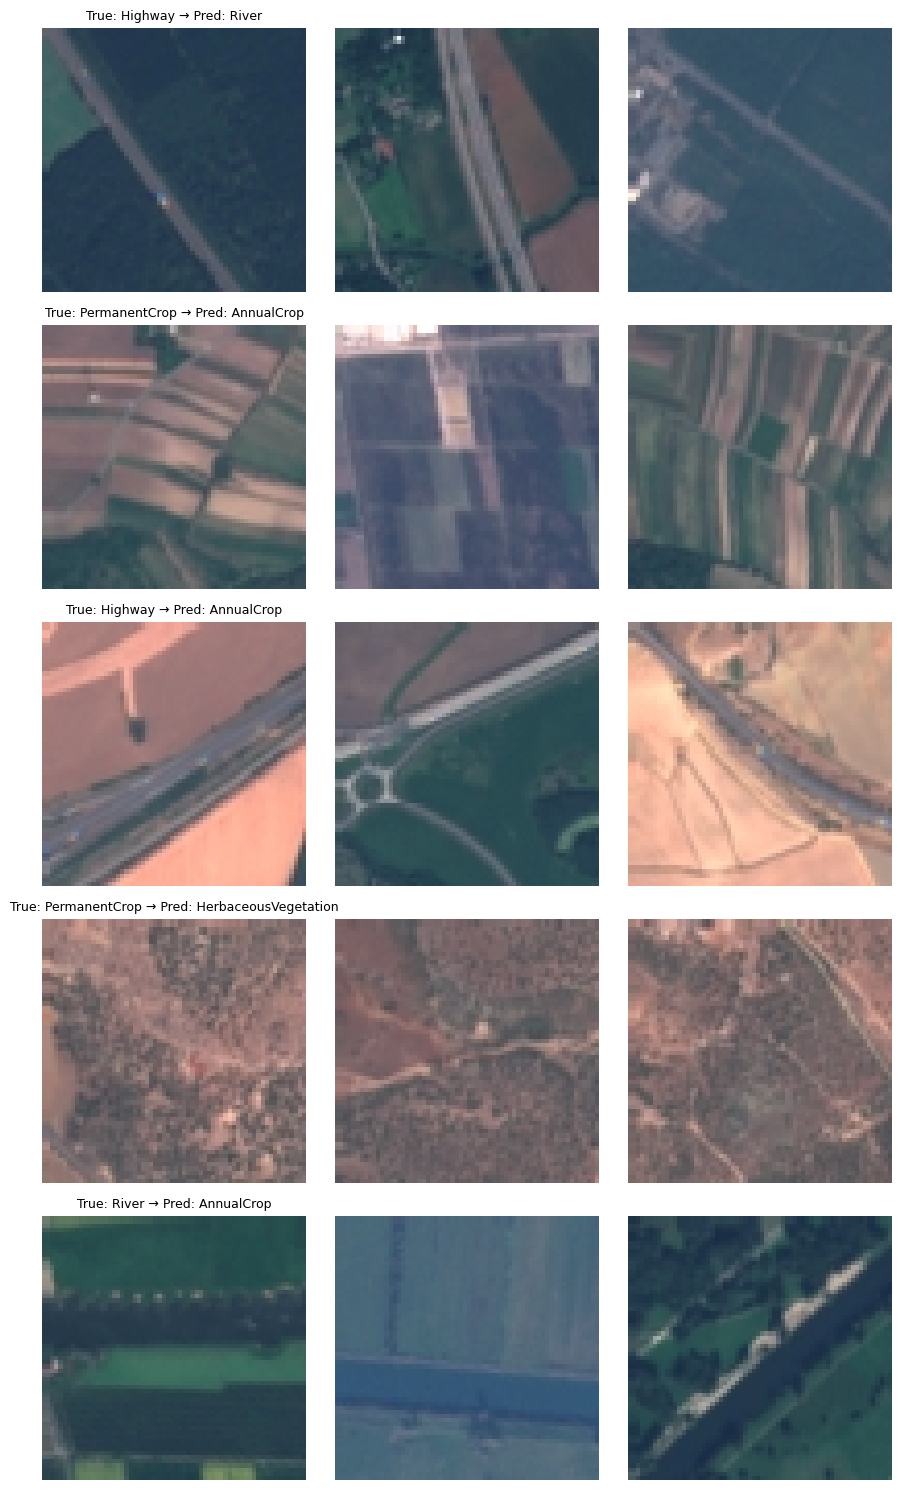

In [21]:
fig, axes = plt.subplots(
    len(top5_pairs),
    3,
    figsize=(9, 3 * len(top5_pairs))
)

axes = np.array(axes).reshape(len(top5_pairs), 3)

for row, (true_idx, pred_idx) in enumerate(top5_pairs):

    # Find up to 3 examples of this exact confusion pair
    matching = [
        val_image_indices[i]
        for i in range(len(val_labels))
        if val_labels[i] == true_idx and val_preds[i] == pred_idx
    ][:3]

    for col in range(3):
        ax = axes[row, col]

        if col < len(matching):
            image, _ = eurosat_dataset[matching[col]]

            img_display = image.numpy().transpose(1, 2, 0)
            img_display = np.clip(
                (img_display * 0.5) + 0.5,
                0,
                1
            )

            ax.imshow(img_display)

        ax.axis("off")

        if col == 0:
            ax.set_title(
                f"True: {class_names[true_idx]} → "
                f"Pred: {class_names[pred_idx]}",
                fontsize=9
            )

plt.tight_layout()
plt.show()

### Error Analysis Observations

The visual examples show that most classification errors occur between classes
with similar visual characteristics from a satellite perspective.

Possible reasons for confusion include:

- Similar colors and textures between different land-use categories.
- Limited spatial details because images are resized to 64×64 pixels.
- Some classes share similar landscape patterns when viewed from above.

The confusion examples highlight areas where additional data, higher-resolution
imagery, or more advanced architectures could improve classification
performance.

## Conclusion

- **Spatial leakage**: compared block-split vs random-split validation
  accuracy on a fast baseline CNN and reported the gap, with a written
  explanation of why leakage under a random split would show up as
  inflated accuracy.
- **UC Merced full evaluation**: re-ran the fine-tuned model on all UC
  Merced classes and presented per-class F1 as a clean table.
- **Error analysis**: identified the top-5 most frequent misclassification
  pairs on EuroSAT validation, showed example images for each, and gave a
  hypothesis for each failure.